In [1]:
import sys, site, platform
print(sys.executable)
print(platform.python_version())
print(site.getsitepackages() if hasattr(site, "getsitepackages") else "no getsitepackages")
print(site.getusersitepackages())

/Library/Frameworks/Python.framework/Versions/3.14/bin/python3
3.14.0
['/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages']
/Users/wukezhang416/Library/Python/3.14/lib/python/site-packages


In [2]:
import os
os.listdir()

['Republicans_house.csv',
 'Democrats_both_chambers.csv',
 'Democrats_senate.csv',
 'Republicans_senate.csv',
 'Democrats_house.csv',
 'Republicans_both_chambers.csv',
 '.ipynb_checkpoints',
 'analysis.ipynb']

In [3]:
import sys
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

pandas: 2.3.3
numpy: 2.3.4
sklearn: 1.7.2


In [5]:
import os
import pandas as pd

files = [f for f in os.listdir() if f.endswith(".csv")]

dfs = []
for f in files:
    party = "Democrat" if f.startswith("Democrats_") else "Republican"
    chamber = "house" if "house" in f else ("senate" if "senate" in f else "both")
    df = pd.read_csv(f)
    df["party"] = party
    df["chamber"] = chamber
    df["source_file"] = f
    dfs.append(df)

tweets = pd.concat(dfs, ignore_index=True)

tweets.shape, tweets.columns.tolist()[:20]

((301854, 15),
 ['tweet_id',
  'tweet_url',
  'tweet_date',
  'user_id',
  'user_url',
  'user_name',
  'user_created',
  'tweet_content',
  'tweet_views',
  'UserId',
  'Party',
  'Member',
  'party',
  'chamber',
  'source_file'])

In [6]:
import pandas as pd
import numpy as np
import re

# 一 最小必要清洗/去重/统一标签
tweets = tweets.copy()

# 去掉 tweet_content 为空的
tweets["tweet_content"] = tweets["tweet_content"].astype(str)
tweets = tweets[tweets["tweet_content"].str.strip().ne("")]

# 去重（按 tweet_id
if "tweet_id" in tweets.columns:
    tweets = tweets.drop_duplicates(subset=["tweet_id"])

# 只保留两党（防止有其它值或者空值）
tweets = tweets[tweets["party"].isin(["Democrat", "Republican"])].copy()

tweets.shape, tweets["party"].value_counts()


# 二 文本清洗（给 TF-IDF 和聚类用
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"http\S+", " ", s)
    s = re.sub(r"@\w+", " ", s) 
    s = re.sub(r"#", " ", s) 
    s = re.sub(r"[^a-z\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

tweets["clean_text"] = tweets["tweet_content"].map(clean_text)

# （去掉太短的推文）
tweets["n_words"] = tweets["clean_text"].str.split().map(len)
tweets = tweets[tweets["n_words"] >= 3].copy()

tweets[["tweet_content", "clean_text", "party"]].head()

,tweet_content,clean_text,party
0,I will always support Israel's right to defend...,i will always support israel's right to defend...,Republican
1,If Alejandro Mayorkas doesn’t deserve to be im...,if alejandro mayorkas doesn t deserve to be im...,Republican
2,I echo the sentiments that President Trump exp...,i echo the sentiments that president trump exp...,Republican
3,I'm very sorry to hear of the passing of Dr. B...,i'm very sorry to hear of the passing of dr be...,Republican
4,The U.S. must stand behind Israel as they defe...,the u s must stand behind israel as they defen...,Republican


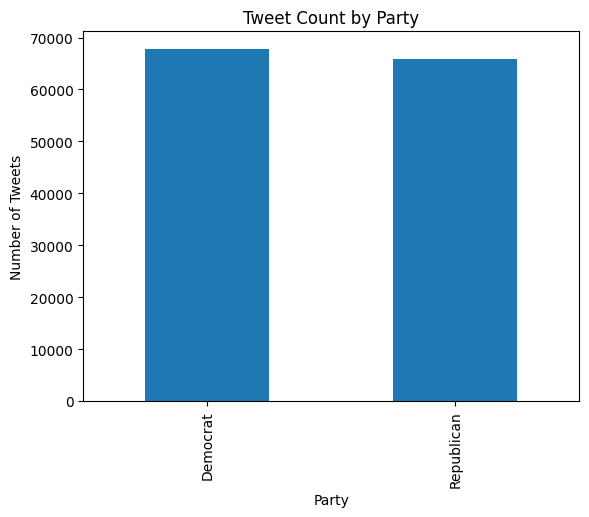

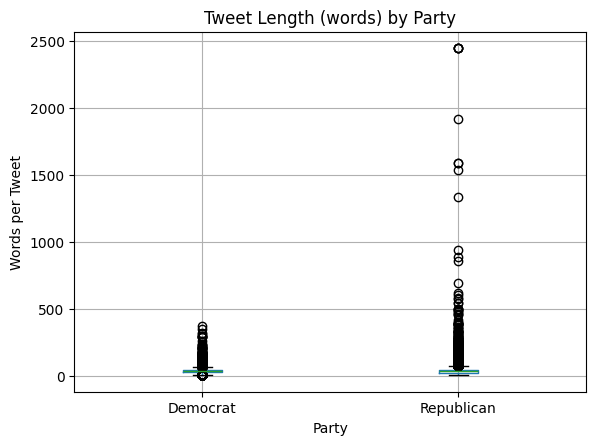

/var/folders/vl/z0bg_35d7dnbhzj_6y68zgvh0000gn/T/ipykernel_11175/818067607.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tweets["month"] = tweets["tweet_date"].dt.to_period("M").dt.to_timestamp()


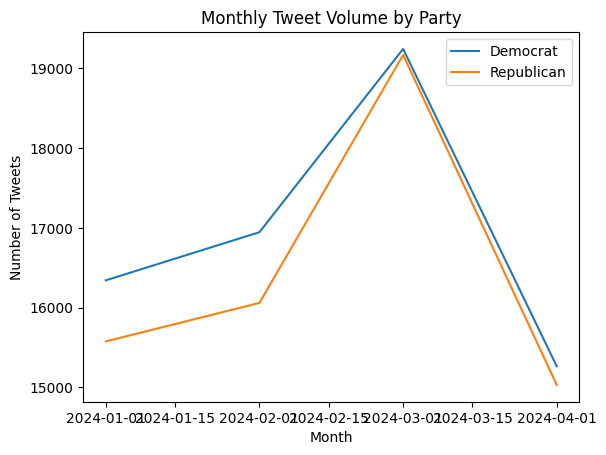

In [7]:
import matplotlib.pyplot as plt
# 3.1 党派 tweet 数量
counts = tweets["party"].value_counts()
counts.plot(kind="bar")
plt.title("Tweet Count by Party")
plt.xlabel("Party")
plt.ylabel("Number of Tweets")
plt.show()

# 3.2 tweet 长度分布（用词数）
tweets.boxplot(column="n_words", by="party")
plt.title("Tweet Length (words) by Party")
plt.suptitle("")
plt.xlabel("Party")
plt.ylabel("Words per Tweet")
plt.show()

# 3.3 时间趋势（每月 tweet 数）
tweets["tweet_date"] = pd.to_datetime(tweets["tweet_date"], errors="coerce", utc=True)
tweets = tweets.dropna(subset=["tweet_date"]).copy()
tweets["month"] = tweets["tweet_date"].dt.to_period("M").dt.to_timestamp()

monthly = tweets.groupby(["month", "party"]).size().reset_index(name="n")

for party in ["Democrat", "Republican"]:
    subset = monthly[monthly["party"] == party]
    plt.plot(subset["month"], subset["n"], label=party)

plt.title("Monthly Tweet Volume by Party")
plt.xlabel("Month")
plt.ylabel("Number of Tweets")
plt.legend()
plt.show()

In [8]:
# Part A
import time, datetime, os, sys
import numpy as np
import pandas as pd

def stamp(msg):
    now = datetime.datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {msg}", flush=True)

class Timer:
    def __init__(self, name):
        self.name = name
    def __enter__(self):
        stamp(f"START: {self.name}")
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, exc_type, exc, tb):
        t = time.perf_counter() - self.t0
        stamp(f"END: {self.name} | {t:.2f}s")

In [9]:
# Part B
SEED = 42
rng = np.random.RandomState(SEED)

stamp(f"full tweets size = {tweets.shape}")

tweets = tweets.dropna(subset=["clean_text", "party"]).copy()
tweets["party"] = tweets["party"].astype(str)

stamp(f"after dropna size = {tweets.shape}")
stamp("party distribution:")
print(tweets["party"].value_counts(), flush=True)

SUP_N = 100000
if len(tweets) > SUP_N:
    sup_df = tweets.sample(n=SUP_N, random_state=SEED).copy()
else:
    sup_df = tweets.copy()

stamp(f"supervised sample size = {sup_df.shape}")

UNSUP_N = 30000
if len(tweets) > UNSUP_N:
    unsup_df = tweets.sample(n=UNSUP_N, random_state=SEED).copy()
else:
    unsup_df = tweets.copy()

stamp(f"unsupervised sample size = {unsup_df.shape}")

[21:00:46] full tweets size = (133632, 18)
[21:00:46] after dropna size = (133632, 18)
[21:00:46] party distribution:
party
Democrat      67797
Republican    65835
Name: count, dtype: int64
[21:00:46] supervised sample size = (100000, 18)
[21:00:46] unsupervised sample size = (30000, 18)


In [10]:
# Part C1
from sklearn.model_selection import train_test_split

X = sup_df["clean_text"].astype(str)
y = sup_df["party"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

stamp(f"train size = {len(X_train)}, test size = {len(X_test)}")

[21:00:47] train size = 80000, test size = 20000


In [11]:
# C2
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9,
    max_features=60000,
    sublinear_tf=True
)

with Timer("TF-IDF fit_transform"):
    Xtr_tfidf = tfidf.fit_transform(X_train)
    Xte_tfidf = tfidf.transform(X_test)

stamp(f"Xtr_tfidf shape = {Xtr_tfidf.shape}, nnz = {Xtr_tfidf.nnz}")
stamp(f"Xte_tfidf shape = {Xte_tfidf.shape}, nnz = {Xte_tfidf.nnz}")

[21:00:47] START: TF-IDF fit_transform
[21:00:49] END: TF-IDF fit_transform | 2.61s
[21:00:49] Xtr_tfidf shape = (80000, 53535), nnz = 1929416
[21:00:49] Xte_tfidf shape = (20000, 53535), nnz = 472442


In [12]:
# C3
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "LogReg": LogisticRegression(max_iter=3000),
    "LinearSVM": LinearSVC(),
    "MultinomialNB": MultinomialNB()
}

scoring = {
    "acc": "accuracy",
    "f1": "f1_macro",
    "prec": "precision_macro",
    "rec": "recall_macro"
}

rows = []
for name, model in models.items():
    stamp(f"CV running: {name}")
    with Timer(f"CV {name}"):
        out = cross_validate(model, Xtr_tfidf, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {
        "model": name,
        "acc_mean": out["test_acc"].mean(),
        "acc_std": out["test_acc"].std(),
        "f1_mean": out["test_f1"].mean(),
        "f1_std": out["test_f1"].std()
    }
    rows.append(row)

cv_table = pd.DataFrame(rows).sort_values("f1_mean", ascending=False)
stamp("CV summary table:")
display(cv_table)

[21:00:50] CV running: LogReg
[21:00:50] START: CV LogReg
[21:00:51] END: CV LogReg | 1.39s
[21:00:51] CV running: LinearSVM
[21:00:51] START: CV LinearSVM
[21:00:52] END: CV LinearSVM | 1.40s
[21:00:52] CV running: MultinomialNB
[21:00:52] START: CV MultinomialNB
[21:00:53] END: CV MultinomialNB | 0.94s
[21:00:53] CV summary table:


,model,acc_mean,acc_std,f1_mean,f1_std
1,LinearSVM,0.850137,0.002588,0.850083,0.002603
0,LogReg,0.842612,0.002952,0.842486,0.002950
2,MultinomialNB,0.826100,0.002536,0.825751,0.002562


In [13]:
# C4
from sklearn.model_selection import GridSearchCV

lr_grid = {
    "C": [0.1, 1, 3, 10],
    "penalty": ["l2"]
}
svm_grid = {
    "C": [0.1, 1, 3, 10]
}

with Timer("GridSearch LogReg"):
    gs_lr = GridSearchCV(
        LogisticRegression(max_iter=3000),
        lr_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=2
    )
    gs_lr.fit(Xtr_tfidf, y_train)

stamp(f"best LogReg params = {gs_lr.best_params_}")
stamp(f"best LogReg CV f1 = {gs_lr.best_score_:.4f}")

with Timer("GridSearch LinearSVM"):
    gs_svm = GridSearchCV(
        LinearSVC(),
        svm_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=2
    )
    gs_svm.fit(Xtr_tfidf, y_train)

stamp(f"best LinearSVM params = {gs_svm.best_params_}")
stamp(f"best LinearSVM CV f1 = {gs_svm.best_score_:.4f}")

[21:00:53] START: GridSearch LogReg
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[21:00:55] END: GridSearch LogReg | 1.52s
[21:00:55] best LogReg params = {'C': 10, 'penalty': 'l2'}
[21:00:55] best LogReg CV f1 = 0.8512
[21:00:55] START: GridSearch LinearSVM
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[21:00:58] END: GridSearch LinearSVM | 3.04s
[21:00:58] best LinearSVM params = {'C': 1}
[21:00:58] best LinearSVM CV f1 = 0.8501


[21:00:58] START: fit best model on full train
[21:00:58] END: fit best model on full train | 0.27s
[21:00:58] START: predict test
[21:00:58] END: predict test | 0.00s
[21:00:58] classification report (test):
              precision    recall  f1-score   support

    Democrat       0.85      0.87      0.86     10148
  Republican       0.86      0.85      0.85      9852

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



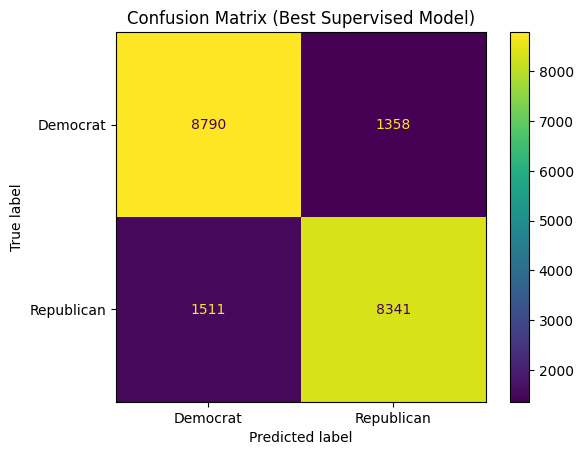

In [14]:
# C5
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = gs_lr.best_estimator_
with Timer("fit best model on full train"):
    best_model.fit(Xtr_tfidf, y_train)

with Timer("predict test"):
    pred = best_model.predict(Xte_tfidf)

stamp("classification report (test):")
print(classification_report(y_test, pred), flush=True)

cm = confusion_matrix(y_test, pred, labels=["Democrat", "Republican"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Democrat", "Republican"])
disp.plot()
plt.title("Confusion Matrix (Best Supervised Model)")
plt.show()

In [15]:
# Part D Feature importance

feature_names = np.array(tfidf.get_feature_names_out())

best_model = LinearSVC(C=gs_svm.best_params_["C"])
best_model.fit(Xtr_tfidf, y_train)

coefs = best_model.coef_[0]

top_k = 20
top_pos = np.argsort(coefs)[-top_k:][::-1]
top_neg = np.argsort(coefs)[:top_k]

stamp("Top features pushing toward Republican:")
for i in top_pos:
    print(feature_names[i], round(coefs[i], 3))

stamp("Top features pushing toward Democrat:")
for i in top_neg:
    print(feature_names[i], round(coefs[i], 3))

[21:00:59] Top features pushing toward Republican:
biden 4.622
northeastohio 4.433
illegal immigrants 4.166
iowa 3.934
utah 3.648
iowans 3.631
ia 3.61
kansans 3.558
nebraska 3.519
bidenomics 3.508
arkansas 3.495
president trump 3.327
ks 3.2
team young 2.953
idaho 2.919
bidenflation 2.878
arindc 2.858
kansas 2.847
wyoming 2.809
west virginia 2.746
[21:00:59] Top features pushing toward Democrat:
nevada -3.307
il -3.211
ri -3.199
reproductive -3.017
wa -2.96
republicans -2.875
new mexico -2.802
netanyahu -2.722
hawai -2.681
maga -2.675
delaware -2.672
democracy -2.66
child care -2.644
kansas city -2.616
peopleoverpolitics -2.588
arizonans -2.539
rhode -2.43
nh -2.413
connecticut -2.351
equitable -2.323


In [16]:
# Part E Ablation + Sensitivity
# Ablation：unigram vs (1,2) bigram
from sklearn.model_selection import cross_val_score

def cv_f1_for_vectorizer(ngram_range):
    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        min_df=5,
        max_df=0.9,
        max_features=60000,
        sublinear_tf=True
    )
    with Timer(f"ablation vec {ngram_range}"):
        Xt = vec.fit_transform(X_train)
    model = LogisticRegression(max_iter=3000, C=gs_lr.best_params_.get("C", 1.0))
    with Timer(f"ablation cv {ngram_range}"):
        scores = cross_val_score(model, Xt, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    return scores.mean(), scores.std()

res = []
for ng in [(1,1), (1,2)]:
    stamp(f"ablation running ngram={ng}")
    m, s = cv_f1_for_vectorizer(ng)
    res.append({"ngram": str(ng), "f1_mean": m, "f1_std": s})

ablation_table = pd.DataFrame(res)
stamp("ablation table:")
display(ablation_table)

[21:00:59] ablation running ngram=(1, 1)
[21:00:59] START: ablation vec (1, 1)
[21:00:59] END: ablation vec (1, 1) | 0.61s
[21:00:59] START: ablation cv (1, 1)
[21:01:00] END: ablation cv (1, 1) | 0.35s
[21:01:00] ablation running ngram=(1, 2)
[21:01:00] START: ablation vec (1, 2)
[21:01:02] END: ablation vec (1, 2) | 2.15s
[21:01:02] START: ablation cv (1, 2)
[21:01:02] END: ablation cv (1, 2) | 0.49s
[21:01:02] ablation table:


,ngram,f1_mean,f1_std
0,"(1, 1)",0.834377,0.002807
1,"(1, 2)",0.851167,0.002891


[21:01:02] sensitivity running C=0.05
[21:01:03] sensitivity running C=0.1
[21:01:03] sensitivity running C=0.3
[21:01:03] sensitivity running C=1
[21:01:04] sensitivity running C=3
[21:01:04] sensitivity running C=10


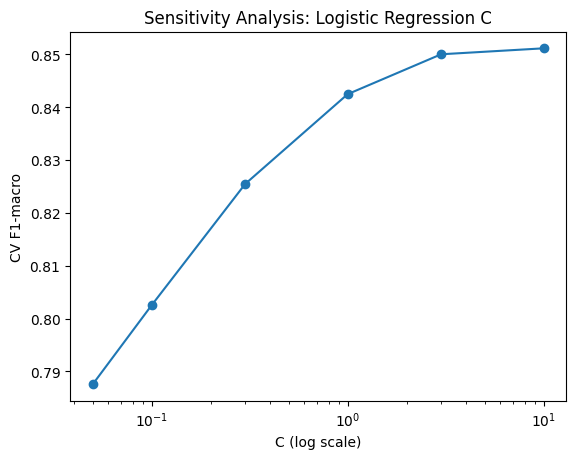

,C,f1_mean,f1_std
0,0.05,0.787553,0.001603
1,0.10,0.802539,0.001907
2,0.30,0.825486,0.001686
3,1.00,0.842486,0.002950
4,3.00,0.850040,0.001585
5,10.00,0.851167,0.002891


In [17]:
# E2 sensitivity
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

Cs = [0.05, 0.1, 0.3, 1, 3, 10]
means = []
stds = []

for c in Cs:
    stamp(f"sensitivity running C={c}")
    model = LogisticRegression(max_iter=3000, C=c)
    scores = cross_val_score(model, Xtr_tfidf, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    means.append(scores.mean())
    stds.append(scores.std())

plt.plot(Cs, means, marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("CV F1-macro")
plt.title("Sensitivity Analysis: Logistic Regression C")
plt.show()

sens_table = pd.DataFrame({"C": Cs, "f1_mean": means, "f1_std": stds})
display(sens_table)

In [18]:
# Part F Failure analysis
best_model = gs_lr.best_estimator_
best_model.fit(Xtr_tfidf, y_train)
pred = best_model.predict(Xte_tfidf)

err_mask = (pred != y_test.values)
err_idx = np.where(err_mask)[0]

stamp(f"misclassified count = {len(err_idx)} out of {len(y_test)}")

show_n = min(10, len(err_idx))
pick = err_idx[:show_n]

err_rows = []
for i in pick:
    err_rows.append({
        "true": y_test.values[i],
        "pred": pred[i],
        "text": X_test.iloc[i][:280]
    })

err_df = pd.DataFrame(err_rows)
display(err_df)

[21:01:05] misclassified count = 2869 out of 20000


,true,pred,text
0,Republican,Democrat,as the situation worsens at professor massad h...
1,Republican,Democrat,what an absolute tragedy my prayers are with t...
2,Democrat,Republican,i am extremely concerned about the invasion of...
3,Republican,Democrat,rt soybean growers are concerned about the rec...
4,Republican,Democrat,i had the privilege of speaking with members o...
5,Democrat,Republican,stay tuned for more information on the congres...
6,Democrat,Republican,good news this week the house unanimously pass...
7,Republican,Democrat,thanks to the for stopping by my office to dis...
8,Republican,Democrat,american families can t afford to wait for us ...
9,Democrat,Republican,passenger safety is non negotiable these are c...


In [20]:
# Part G Tree-based supervised family

from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

rf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=5,
        max_df=0.9,
        max_features=60000,
        sublinear_tf=True
    )),
    ("svd", TruncatedSVD(n_components=300, random_state=SEED)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        max_depth=None
    ))
])

stamp("CV running: RandomForest (TFIDF+SVD+RF)")
with Timer("CV RF"):
    out_rf = cross_validate(
        rf_pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

rf_row = {
    "model": "TFIDF+SVD+RandomForest",
    "acc_mean": out_rf["test_acc"].mean(),
    "acc_std": out_rf["test_acc"].std(),
    "f1_mean": out_rf["test_f1"].mean(),
    "f1_std": out_rf["test_f1"].std()
}

cv_table2 = pd.concat([cv_table, pd.DataFrame([rf_row])], ignore_index=True)
display(cv_table2.sort_values("f1_mean", ascending=False))

[21:01:14] CV running: RandomForest (TFIDF+SVD+RF)
[21:01:14] START: CV RF
[CV] END ..................................C=0.1, penalty=l2; total time=   0.1s
[CV] END ....................................C=3, penalty=l2; total time=   0.2s
[CV] END ................................................C=3; total time=   1.2s
[CV] END ....................................C=3, penalty=l2; total time=   0.3s
[CV] END ..............................................C=0.1; total time=   0.4s
[CV] END ...............................................C=10; total time=   1.6s
[CV] END ....................................C=1, penalty=l2; total time=   0.2s
[CV] END ..............................................C=0.1; total time=   0.3s
[CV] END ................................................C=3; total time=   1.1s
[CV] END ..................................C=0.1, penalty=l2; total time=   0.2s
[CV] END ...................................C=10, penalty=l2; total time=   0.3s
[CV] END .........................

,model,acc_mean,acc_std,f1_mean,f1_std
0,LinearSVM,0.850137,0.002588,0.850083,0.002603
1,LogReg,0.842612,0.002952,0.842486,0.002950
2,MultinomialNB,0.826100,0.002536,0.825751,0.002562
3,TFIDF+SVD+RandomForest,0.769050,0.001089,0.767596,0.001149


[CV] END ....................................C=3, penalty=l2; total time=   0.2s
[CV] END ................................................C=3; total time=   1.2s
[CV] END ....................................C=3, penalty=l2; total time=   0.3s
[CV] END ................................................C=1; total time=   0.7s
[CV] END ...............................................C=10; total time=   1.8s
[CV] END ..................................C=0.1, penalty=l2; total time=   0.1s
[CV] END ...................................C=10, penalty=l2; total time=   0.4s
[CV] END ................................................C=1; total time=   0.8s
[CV] END ..................................C=0.1, penalty=l2; total time=   0.2s
[CV] END ...................................C=10, penalty=l2; total time=   0.3s
[CV] END ................................................C=3; total time=   1.8s
[CV] END ..................................C=0.1, penalty=l2; total time=   0.2s
[CV] END ...................

In [22]:
## Part H Unsupervised Learning
# Part H1 unsupervised setup

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

stamp("start unsupervised pipeline")

X_unsup_text = unsup_df["clean_text"].astype(str)

unsup_tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9,
    max_features=60000,
    sublinear_tf=True
)

with Timer("unsup tfidf"):
    X_unsup_tfidf = unsup_tfidf.fit_transform(X_unsup_text)

stamp(f"X_unsup_tfidf shape = {X_unsup_tfidf.shape}")

with Timer("unsup svd 50d"):
    unsup_svd_50 = TruncatedSVD(n_components=50, random_state=SEED)
    X_unsup_50 = unsup_svd_50.fit_transform(X_unsup_tfidf)

stamp(f"X_unsup_50 shape = {X_unsup_50.shape}")

K = 5
with Timer("unsup kmeans"):
    kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    cluster_labels = kmeans.fit_predict(X_unsup_50)

stamp("unsupervised clustering done")

[21:57:19] start unsupervised pipeline
[21:57:19] START: unsup tfidf
[21:57:20] END: unsup tfidf | 0.84s
[21:57:20] X_unsup_tfidf shape = (30000, 20613)
[21:57:20] START: unsup svd 50d
[21:57:20] END: unsup svd 50d | 0.22s
[21:57:20] X_unsup_50 shape = (30000, 50)
[21:57:20] START: unsup kmeans
[21:57:21] END: unsup kmeans | 0.27s
[21:57:21] unsupervised clustering done


[21:57:31] START: unsup svd 2d
[21:57:31] END: unsup svd 2d | 0.08s


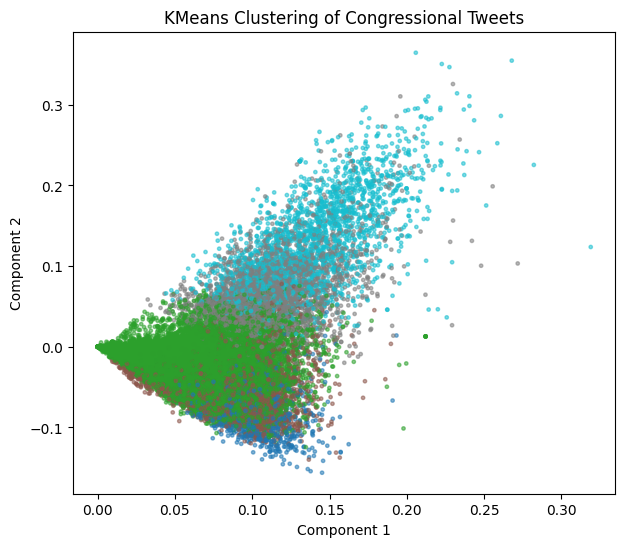

In [23]:
# Part H2 cluster visualization

import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

with Timer("unsup svd 2d"):
    unsup_svd_2 = TruncatedSVD(n_components=2, random_state=SEED)
    X_unsup_2d = unsup_svd_2.fit_transform(X_unsup_tfidf)

plt.figure(figsize=(7,6))
plt.scatter(
    X_unsup_2d[:, 0],
    X_unsup_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=6,
    alpha=0.55
)

plt.title("KMeans Clustering of Congressional Tweets")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

,cluster,count
0,0,1330
1,1,20101
2,2,3742
3,3,2691
4,4,2136


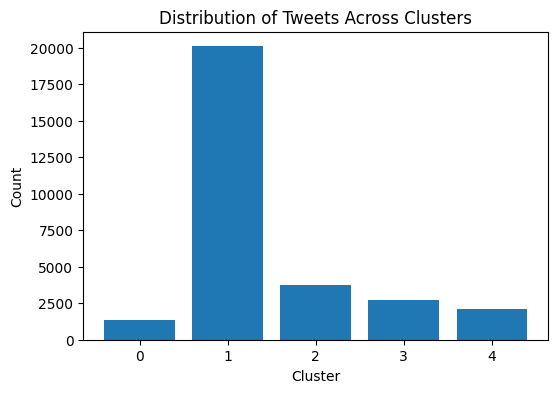

In [24]:
# Part H3 cluster distribution

import pandas as pd

cluster_count_table = pd.DataFrame({
    "cluster": cluster_labels
})["cluster"].value_counts().sort_index().reset_index()

cluster_count_table.columns = ["cluster", "count"]
display(cluster_count_table)

plt.figure(figsize=(6,4))
plt.bar(cluster_count_table["cluster"].astype(str), cluster_count_table["count"])
plt.title("Distribution of Tweets Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [25]:
# Part H4 top words for each cluster

terms = np.array(unsup_tfidf.get_feature_names_out())
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

top_word_rows = []

for i in range(K):
    top_words = terms[order_centroids[i, :12]]
    top_word_rows.append({
        "cluster": i,
        "top_words": ", ".join(top_words)
    })

cluster_keywords_table = pd.DataFrame(top_word_rows)
display(cluster_keywords_table)

,cluster,top_words
0,0,"aanhpi, abandoning, abandoned, abbey, abdullah..."
1,1,"aanhpi, abandon, ability control, abetting, ab..."
2,2,"aanhpi, abhorrent, abdication, abby, aaron, ab..."
3,3,"aanhpi, aapi, aanhpi communities, abbey, abdul..."
4,4,"aanhpi, aanhpi communities, aaron, abandoned, ..."


[22:05:16] running kmeans sensitivity k=3
[22:05:17] running kmeans sensitivity k=4
[22:05:17] running kmeans sensitivity k=5
[22:05:17] running kmeans sensitivity k=6
[22:05:17] running kmeans sensitivity k=7
[22:05:18] running kmeans sensitivity k=8


,k,inertia
0,3,1981.758537
1,4,1933.396972
2,5,1894.044851
3,6,1852.448634
4,7,1816.447320
5,8,1783.626253


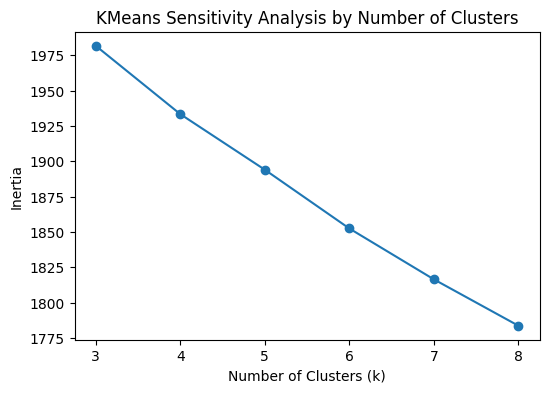

In [26]:
# Part H5 sensitivity analysis for k

ks = [3, 4, 5, 6, 7, 8]
inertias = []

for k in ks:
    stamp(f"running kmeans sensitivity k={k}")
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_unsup_50)
    inertias.append(km.inertia_)

sens_unsup_table = pd.DataFrame({
    "k": ks,
    "inertia": inertias
})

display(sens_unsup_table)

plt.figure(figsize=(6,4))
plt.plot(ks, inertias, marker="o")
plt.title("KMeans Sensitivity Analysis by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()